<a href="https://colab.research.google.com/github/Nemosimes/NLP-Project/blob/MS2/ms2_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile, tarfile, os

archive_path = "/content/drive/MyDrive/Nlp/Project/ms2Data.zip"   # change to your filename

# For .zip
with zipfile.ZipFile(archive_path, 'r') as z:
    z.extractall("/content/dataset")

# For .tar.gz
# with tarfile.open(archive_path, 'r:gz') as t:
#     t.extractall("/content/dataset")

# See what's inside
for root, dirs, files in os.walk("/content/dataset"):
    for f in files:
        print(os.path.join(root, f))

/content/dataset/citizen_kane_test_set.json
/content/dataset/physics_movement_qa_dataset.json
/content/dataset/f35_test_set.json
/content/dataset/samurai_test_set.json
/content/dataset/samurai_qa_dataset.json
/content/dataset/taj_mahal_qa_dataset.json
/content/dataset/russia_empire_test_set.json
/content/dataset/citizen_kane_qa_dataset.json
/content/dataset/f35_qa_dataset.json
/content/dataset/octopus_qa_dataset.json
/content/dataset/taj_mahal_test_set.json
/content/dataset/octopus_test_set.json
/content/dataset/physics_movement_test_set.json
/content/dataset/russia_empire_qa_dataset.json


In [3]:
import glob
import json
import os

# Define your directory (use '.' for the main content folder or your Drive path)
path_to_json = "/content/dataset"
json_pattern = os.path.join(path_to_json, '*.json')
file_list = glob.glob(json_pattern)

data = []

for file in file_list:
    with open(file, 'r') as f:
        # Load each file and append to our list
        data.append(json.load(f))

print(f"Loaded {len(data)} files.")



Loaded 14 files.


In [4]:
import json, os, glob
import pandas as pd

# Set the path where your extracted files are
data_dir = "/content/dataset"  # adjust if needed

train_data = []
test_data  = []

for fpath in glob.glob(os.path.join(data_dir, "*.json")):
    fname = os.path.basename(fpath)
    with open(fpath, "r", encoding="utf-8") as f:
        records = json.load(f)  # list of {question, context, answer}

    if "test" in fname.lower():
        test_data.extend(records["data"])
    else:
        train_data.extend(records["data"])


print(f"Train samples: {len(train_data)}")
print(f"Test  samples: {len(test_data)}")
print("Sample:", train_data[0])

Train samples: 7
Test  samples: 7
Sample: {'title': 'physics_movement_training_final', 'paragraphs': [{'context': 'الفلاسفة الطبيعيون الأوائل مثل طاليس وأنكسيمناس وهيرقليطس اختلفوا حول أصل الكون. لكن رغم اختلافهم، كانت هناك فكرة مشتركة بينهم. كل مادة من دول بتتحرك وبتتحول طول الوقت، سواء كانت ماء أو هواء أو نار.', 'qas': [{'id': 'Q1', 'question': 'ما الفكرة المشتركة بين الفلاسفة الطبيعيين الأوائل حول الكون؟', 'answers': [{'text': 'كل مادة من دول بتتحرك وبتتحول طول الوقت'}]}]}, {'context': 'هيرقليطس كان يرى أن النار تمثل التغير المستمر. اختارها لأنها دائمًا في حالة حركة وتحول. بسبب حركتها المجنونة والمستمرة، اعتبرها أفضل تعبير عن طبيعة الكون.', 'qas': [{'id': 'Q2', 'question': 'لماذا اختار هيرقليطس النار كأصل للعالم؟', 'answers': [{'text': 'بسبب حركتها المجنونة والمستمرة'}]}]}, {'context': 'رغم اختلاف الفلاسفة، إلا أنهم اتفقوا على فكرة أساسية. كانوا شايفين إن الحركة هي عصب الوجود بالكامل. كل شيء في الكون في حالة تغير مستمر.', 'qas': [{'id': 'Q3', 'question': 'ماذا كان رأي الفلاسفة حول أ

In [5]:
def flatten(data):
    rows = []

    for item in data:
        title = item["title"]

        for para in item["paragraphs"]:
            context = para["context"]

            for qa in para["qas"]:
                question = qa["question"]
                answer = qa["answers"][0]["text"] if qa["answers"] else None

                rows.append({
                    "title": title,
                    "context": context,
                    "question": question,
                    "answer": answer
                })

    return rows

train_df = pd.DataFrame(flatten(train_data))
test_df = pd.DataFrame(flatten(test_data))

In [6]:

# Verify columns
#print(train_df.columns)
train_df.head()

,title,context,question,answer
0,physics_movement_training_final,الفلاسفة الطبيعيون الأوائل مثل طاليس وأنكسيمنا...,ما الفكرة المشتركة بين الفلاسفة الطبيعيين الأو...,كل مادة من دول بتتحرك وبتتحول طول الوقت
1,physics_movement_training_final,هيرقليطس كان يرى أن النار تمثل التغير المستمر....,لماذا اختار هيرقليطس النار كأصل للعالم؟,بسبب حركتها المجنونة والمستمرة
2,physics_movement_training_final,رغم اختلاف الفلاسفة، إلا أنهم اتفقوا على فكرة ...,ماذا كان رأي الفلاسفة حول أهمية الحركة؟,الحركة هي عصب الوجود بالكامل
3,physics_movement_training_final,مع ازدياد نفوذ الساموراي، بدأ احترام الناس لهم...,لماذا أصبح الناس يخافون من الساموراي؟,امتلاك السلاح وفرض النظام بالقوة
4,physics_movement_training_final,عالم الأعصاب دانيال وولبرت قدم تفسيرًا مختلفًا...,ماذا يقول عالم الأعصاب دانيال وولبرت عن وظيفة ...,وهي إنتاج سلسلة من الحركات المعقدة


In [7]:
import re

def contains_english(text):
    return bool(re.search(r"[A-Za-z]", str(text)))


cols = ["context", "question", "answer"]

english_rows = train_df[
   train_df[cols].apply(lambda row: any(contains_english(x) for x in row), axis=1)
]

print("Rows with English words:", len(english_rows))
english_rows.head()

Rows with English words: 26


,title,context,question,answer
44,samurai_training_final,طقس سيبوكو هو أن الساموراي بيلبس كيمونو أبيض و...,ما هو طقس Seppuku؟,الساموراي بيلبس كيمونو أبيض ويقوم غارز السيف ف...
66,taj_mahal_video,استخدموا تقنية اسمها Pietra Dura... التطعيم ال...,ما التقنية المستخدمة في زخرفة تاج محل بالأحجار...,Pietra Dura
78,citizen_kane_training_set,في تلك الفترة، اعتمدت أفلام هوليوود على قوالب ...,ما طبيعة أفلام هوليوود قبل Citizen Kane؟,قوالب تقليدية ونهايات سعيدة
85,citizen_kane_training_set,ينطق كين كلمة Rosebud قبل موته. تصبح هذه الكلم...,ما دور كلمة Rosebud؟,لغز لفهم شخصية كين
88,citizen_kane_training_set,تقنية Deep Focus تُظهر جميع عناصر المشهد بوضوح...,ما هي تقنية Deep Focus؟,إظهار جميع العناصر بوضوح


In [8]:
english_rows["english_count"] = train_df.apply(
    lambda row: sum(len(re.findall(r"[A-Za-z]+", str(row[c]))) for c in ["context","question","answer"]),
    axis=1
)

english_rows["english_count"].describe()

/tmp/ipykernel_68507/4000429766.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  english_rows["english_count"] = train_df.apply(


,english_count
count,26.000000
mean,2.423077
std,1.447013
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,8.000000


Dataset contains named entities and scientific English words which were preserved to maintain semantic meaning

In [9]:

import re
def preprocess(text):
    if not isinstance(text, str):
        text = str(text)

    # Step 1 — remove tashkeel FIRST
    text = re.sub(r'[\u0617-\u061A\u064B-\u065F\u0670\u0640]', '', text)

    # Step 2 — remove trailing ا that was left by tanwin fath (ً)
    # e.g. تماماً → تماما → تمام
    text = re.sub(r'ا\b', '', text)   # ← removes ا at end of words

    # Step 3 — normalize alef variants
    text = re.sub(r'[أإآا]', 'ا', text)

    # Step 4 — separate glued Arabic+English
    text = re.sub(r'([\u0600-\u06FF])([A-Za-z])', r'\1 \2', text)
    text = re.sub(r'([A-Za-z])([\u0600-\u06FF])', r'\1 \2', text)

    # Step 4 — remove BOTH question marks and all punctuation
    text = re.sub(r'[؟?،,،.!()\"{}]', ' ', text)          # ← removed \[\] from here
    text = re.sub(r'[^\u0600-\u06FF A-Za-z0-9\s\[\]]', ' ', text)  # ← added \[\] to keep list

    # Step 6 — clean spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test it
test_words = ["تماماً", "أصلًا", "تدريجيًا", "الساموراي،", "كين؟"]
for w in test_words:
    print(f"{w:20} → '{preprocess(w)}'")

# Concatenate question + context as model input
train_df["input"] = train_df["question"].apply(preprocess) + " [SEP] " + train_df["context"].apply(preprocess)
test_df["input"]  = test_df["question"].apply(preprocess)  + " [SEP] " + test_df["context"].apply(preprocess)

train_df["answer"] = train_df["answer"].apply(preprocess)
test_df["answer"]  = test_df["answer"].apply(preprocess)

تماماً               → 'تمام'
أصلًا                → 'اصل'
تدريجيًا             → 'تدريجي'
الساموراي،           → 'الساموراي'
كين؟                 → 'كين'


In [10]:
train_df.head()


,title,context,question,answer,input
0,physics_movement_training_final,الفلاسفة الطبيعيون الأوائل مثل طاليس وأنكسيمنا...,ما الفكرة المشتركة بين الفلاسفة الطبيعيين الأو...,كل مادة من دول بتتحرك وبتتحول طول الوقت,م الفكرة المشتركة بين الفلاسفة الطبيعيين الاوا...
1,physics_movement_training_final,هيرقليطس كان يرى أن النار تمثل التغير المستمر....,لماذا اختار هيرقليطس النار كأصل للعالم؟,بسبب حركته المجنونة والمستمرة,لماذ اختار هيرقليطس النار كاصل للعالم [SEP] هي...
2,physics_movement_training_final,رغم اختلاف الفلاسفة، إلا أنهم اتفقوا على فكرة ...,ماذا كان رأي الفلاسفة حول أهمية الحركة؟,الحركة هي عصب الوجود بالكامل,ماذ كان راي الفلاسفة حول اهمية الحركة [SEP] رغ...
3,physics_movement_training_final,مع ازدياد نفوذ الساموراي، بدأ احترام الناس لهم...,لماذا أصبح الناس يخافون من الساموراي؟,امتلاك السلاح وفرض النظام بالقوة,لماذ اصبح الناس يخافون من الساموراي [SEP] مع ا...
4,physics_movement_training_final,عالم الأعصاب دانيال وولبرت قدم تفسيرًا مختلفًا...,ماذا يقول عالم الأعصاب دانيال وولبرت عن وظيفة ...,وهي انتاج سلسلة من الحركات المعقدة,ماذ يقول عالم الاعصاب دانيال وولبرت عن وظيفة ا...


In [11]:
train_df["input_len"] = train_df["input"].apply(lambda x: len(x.split()))

print(train_df["input_len"].describe())
print(f"Max  : {train_df['input_len'].max()}")
print(f"Mean : {train_df['input_len'].mean():.1f}")
print(f"95th percentile: {train_df['input_len'].quantile(0.95):.0f}")


count    168.000000
mean      20.500000
std        7.785292
min        7.000000
25%       15.000000
50%       18.000000
75%       25.000000
max       53.000000
Name: input_len, dtype: float64
Max  : 53
Mean : 20.5
95th percentile: 33


In [12]:
train_df["answer_len"] = train_df["answer"].apply(lambda x: len(preprocess(x).split()))

print(train_df["answer_len"].describe())
print(f"Max    : {train_df['answer_len'].max()}")
print(f"Mean   : {train_df['answer_len'].mean():.1f}")
print(f"Longest answer: {train_df.loc[train_df['answer_len'].idxmax(), 'answer']}")

count    168.000000
mean       4.761905
std        2.362983
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       12.000000
Name: answer_len, dtype: float64
Max    : 12
Mean   : 4.8
Longest answer: لان التصميم مستوحى من وصف الجنة ويتضمن الماء كعنصر اساسي في المشهد


In [13]:
from collections import Counter

# Build vocab from training data only
all_text = " ".join(train_df["input"].tolist() + train_df["answer"].apply(preprocess).tolist())
tokens   = all_text.split()

print (tokens)

['م', 'الفكرة', 'المشتركة', 'بين', 'الفلاسفة', 'الطبيعيين', 'الاوائل', 'حول', 'الكون', '[SEP]', 'الفلاسفة', 'الطبيعيون', 'الاوائل', 'مثل', 'طاليس', 'وانكسيمناس', 'وهيرقليطس', 'اختلفو', 'حول', 'اصل', 'الكون', 'لكن', 'رغم', 'اختلافهم', 'كانت', 'هناك', 'فكرة', 'مشتركة', 'بينهم', 'كل', 'مادة', 'من', 'دول', 'بتتحرك', 'وبتتحول', 'طول', 'الوقت', 'سواء', 'كانت', 'ماء', 'او', 'هواء', 'او', 'نار', 'لماذ', 'اختار', 'هيرقليطس', 'النار', 'كاصل', 'للعالم', '[SEP]', 'هيرقليطس', 'كان', 'يرى', 'ان', 'النار', 'تمثل', 'التغير', 'المستمر', 'اختاره', 'لانه', 'دائم', 'في', 'حالة', 'حركة', 'وتحول', 'بسبب', 'حركته', 'المجنونة', 'والمستمرة', 'اعتبره', 'افضل', 'تعبير', 'عن', 'طبيعة', 'الكون', 'ماذ', 'كان', 'راي', 'الفلاسفة', 'حول', 'اهمية', 'الحركة', '[SEP]', 'رغم', 'اختلاف', 'الفلاسفة', 'ال', 'انهم', 'اتفقو', 'على', 'فكرة', 'اساسية', 'كانو', 'شايفين', 'ان', 'الحركة', 'هي', 'عصب', 'الوجود', 'بالكامل', 'كل', 'شيء', 'في', 'الكون', 'في', 'حالة', 'تغير', 'مستمر', 'لماذ', 'اصبح', 'الناس', 'يخافون', 'من', 'الساموراي'

In [14]:
english_tokens = []
for token in tokens:
    if contains_english(token) and token != "[SEP]":
        english_tokens.append(token)

print(f"Found {len(english_tokens)} English words/tokens in the vocabulary.")
print("Sample English tokens:", english_tokens)


Found 63 English words/tokens in the vocabulary.
Sample English tokens: ['Seppuku', 'Pietra', 'Dura', 'Citizen', 'Kane', 'Rosebud', 'Rosebud', 'Deep', 'Focus', 'Deep', 'Focus', 'Rosebud', 'Rosebud', 'F', 'Hangar', 'Hangar', 'Test', 'F', 'F', 'F', 'F', 'RAM', 'RCS', 'Radar', 'Cross', 'Section', 'F', 'F', 'F', 'F', 'F', 'Command', 'of', 'the', 'Air', 'Software', 'Software', 'Cephalopoda', 'Cephalo', 'Poda', 'Mantle', 'The', 'European', 'Plain', 'Attack', 'as', 'Defense', 'access', 'Streltsy', 'Play', 'Troops', 'Play', 'Troops', 'Pietra', 'Dura', 'F', 'Hangar', 'RAM', 'Command', 'of', 'the', 'Air', 'Mantle']


In [15]:
vocab    = Counter(tokens)
VOCAB_SIZE_LIMIT = 1000

word2idx = {"<PAD>": 0, "<UNK>": 1, "<SOS>": 2, "<EOS>": 3}
for word, count in vocab.most_common(VOCAB_SIZE_LIMIT):
    if count >= 2:  # only words that appear at least twice
        word2idx[word] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")
print (word2idx)
print (idx2word)

Vocabulary size: 830
{'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3, '[SEP]': 4, 'في': 5, 'م': 6, 'من': 7, 'على': 8, 'ان': 9, 'الى': 10, 'الساموراي': 11, 'لماذ': 12, 'الذي': 13, 'محل': 14, 'هو': 15, 'الحركة': 16, 'كيف': 17, 'الاخطبوط': 18, 'كانت': 19, 'كان': 20, 'عن': 21, 'ماذ': 22, 'اللي': 23, 'روسي': 24, 'كل': 25, 'غير': 26, 'سنة': 27, 'تاج': 28, 'او': 29, 'التي': 30, 'ل': 31, 'لم': 32, 'ال': 33, 'الاساسية': 34, 'جهان': 35, 'F': 36, '35': 37, 'بين': 38, 'زينون': 39, 'بعد': 40, 'الضوء': 41, 'شاه': 42, 'ويلز': 43, 'اول': 44, 'هذه': 45, 'الجسم': 46, 'فيه': 47, 'عشان': 48, 'كين': 49, 'الطائرة': 50, 'حول': 51, 'الكون': 52, 'لانه': 53, 'سبب': 54, 'انه': 55, 'هذ': 56, 'حوالي': 57, 'الطيارة': 58, 'مثل': 59, 'بسبب': 60, 'كانو': 61, 'مع': 62, 'مجرد': 63, 'مم': 64, 'تجربة': 65, 'قبل': 66, 'اي': 67, 'الامبراطور': 68, 'اسم': 69, 'كم': 70, 'عدد': 71, 'تحت': 72, 'الفيلم': 73, 'الفكرة': 74, 'حركة': 75, 'الناس': 76, 'نفس': 77, 'اللحظة': 78, 'سرعة': 79, 'ممكن': 80, 'طاقة': 81, 'تم': 82, 'اليابان': 83

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

MAX_INPUT_LEN  = 64

# Check what longest answer is
max_ans = train_df["answer_len"].max()
print(f"Longest answer: {max_ans} words")

# Then set both to match
MAX_TARGET_LEN = max_ans + 2   # +2 for SOS and EOS

def encode_target(text, max_len=MAX_TARGET_LEN):
    tokens = preprocess(text).split()[:max_len - 2]
    ids  = [word2idx["<SOS>"]]
    ids += [word2idx.get(t, 1) for t in tokens]
    ids.append(word2idx["<EOS>"])
    return ids

def encode(text, max_len):
    tokens = text.split()[:max_len]
    return [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>


# Rebuild dataset with this
class QADataset(Dataset):
    def __init__(self, df):
        self.inputs  = [encode(row["input"], MAX_INPUT_LEN)
                        for _, row in df.iterrows()]
        self.targets = [encode_target(row["answer"])   # ← short + EOS
                        for _, row in df.iterrows()]

    def __len__(self): return len(self.inputs)

    def __getitem__(self, idx):
        return (torch.tensor(self.inputs[idx],  dtype=torch.long),
                torch.tensor(self.targets[idx], dtype=torch.long))

def collate_fn(batch):
    inputs, targets = zip(*batch)  #zip(*batch) unpacks this into two separate tuples: all inputs together, all targets together.
    inputs  = pad_sequence(inputs,  batch_first=True, padding_value=0)
    targets = pad_sequence(targets, batch_first=True, padding_value=0)
    return inputs, targets


Longest answer: 12 words


Model

In [17]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout, bidirectional=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, (hidden, cell) = self.rnn(embedded)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout)
        self.fc  = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell):
        x        = x.unsqueeze(1)                         # (batch, 1)
        embedded = self.dropout(self.embedding(x))         # (batch, 1, embed)
        out, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        pred = self.fc(out.squeeze(1))                     # (batch, vocab_size)
        return pred, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size  = src.shape[0]
        trg_len     = trg.shape[1]
        vocab_size  = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)
        hidden, cell = self.encoder(src)

        dec_input = trg[:, 0]  # <SOS>
        for t in range(1, trg_len):
            out, hidden, cell = self.decoder(dec_input, hidden, cell)
            outputs[:, t, :] = out
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            dec_input = trg[:, t] if teacher_force else out.argmax(1)

        return outputs

In [18]:
print(f"Train samples: {len(train_df)}")
print(f"Test  samples: {len(test_df)}")

Train samples: 168
Test  samples: 72


In [19]:
def predict_answer(model, question, context, max_len=8):
    model.eval()
    inp = preprocess(question) + " [SEP] " + preprocess(context)
    enc = encode(inp, MAX_INPUT_LEN)
    src = torch.tensor(enc, dtype=torch.long).unsqueeze(0).to(DEVICE)

    allowed_tokens = set(enc)
    allowed_tokens.discard(word2idx["<PAD>"])
    allowed_tokens.discard(word2idx["<SOS>"])
    allowed_tokens.discard(word2idx.get("<UNK>", 1))

    with torch.no_grad():
        hidden, cell = model.encoder(src)      # ← use model, not model1

    dec_input = torch.tensor([word2idx["<SOS>"]], dtype=torch.long).to(DEVICE)
    answer_tokens = []
    seen = set()

    for step in range(max_len):
        with torch.no_grad():
            out, hidden, cell = model.decoder(dec_input, hidden, cell)  # ← model

        mask = torch.full(out.shape, -float('inf')).to(DEVICE)
        for idx in allowed_tokens:
            mask[0][idx] = out[0][idx]
        if step == 0:
            mask[0][word2idx["<EOS>"]] = -float('inf')
        for idx in seen:
            mask[0][idx] = -float('inf')

        top_token = mask.argmax(1).item()
        if top_token == word2idx["<EOS>"]:
            break

        word = idx2word.get(top_token, "")
        if word:
            answer_tokens.append(word)
            seen.add(top_token)
        dec_input = torch.tensor([top_token], dtype=torch.long).to(DEVICE)

    return " ".join(answer_tokens)

In [20]:

train_dataset = QADataset(train_df)
test_dataset  = QADataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, collate_fn=collate_fn)

In [21]:
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_DIM  = 64    # was 256 — too big
HIDDEN_DIM = 128   # was 512 — too big
N_LAYERS   = 2
DROPOUT    = 0.5   # increase dropout to fight overfitting

# 3. More epochs with early stopping
N_EPOCHS = 100

# 4. Early stopping
best_val  = float('inf')
patience  = 0
PATIENCE  =12
teacher_forcing_ratio = 0.5

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model1   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

optimizer = torch.optim.Adam(model1.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <PAD>

train_losses, test_losses = [], []

for epoch in range(N_EPOCHS):
  # decay teacher forcing each epoch
    tf_ratio = max(0.1, teacher_forcing_ratio - (epoch * 0.03))

    # --- Train ---
    model1.train()
    epoch_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        output = model1(src, trg, teacher_forcing_ratio=tf_ratio)
        output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
        target = trg[:, 1:].reshape(-1)
        loss   = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model1.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # --- Eval ---
    model1.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in test_loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            output = model1(src, trg, teacher_forcing_ratio=0)
            output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
            target = trg[:, 1:].reshape(-1)
            val_loss += criterion(output, target).item()
    test_losses.append(val_loss / len(test_loader))

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {test_losses[-1]:.4f}")

    if test_losses[-1] < best_val:
        best_val = test_losses[-1]
        patience = 0
        torch.save(model1.state_dict(), "best_model1.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} | Best val loss: {best_val:.4f}")
            break

Epoch 01 | Train Loss: 6.7116 | Val Loss: 6.6630
Epoch 02 | Train Loss: 6.6160 | Val Loss: 6.4141
Epoch 03 | Train Loss: 6.1733 | Val Loss: 5.3758
Epoch 04 | Train Loss: 5.2333 | Val Loss: 4.8165
Epoch 05 | Train Loss: 4.9784 | Val Loss: 4.7210
Epoch 06 | Train Loss: 4.8908 | Val Loss: 4.6922
Epoch 07 | Train Loss: 4.8656 | Val Loss: 4.6803
Epoch 08 | Train Loss: 4.8486 | Val Loss: 4.6467
Epoch 09 | Train Loss: 4.7951 | Val Loss: 4.6365
Epoch 10 | Train Loss: 4.7473 | Val Loss: 4.6249
Epoch 11 | Train Loss: 4.7365 | Val Loss: 4.6107
Epoch 12 | Train Loss: 4.7132 | Val Loss: 4.6006
Epoch 13 | Train Loss: 4.7200 | Val Loss: 4.5930
Epoch 14 | Train Loss: 4.7216 | Val Loss: 4.5770
Epoch 15 | Train Loss: 4.6790 | Val Loss: 4.5682
Epoch 16 | Train Loss: 4.6822 | Val Loss: 4.5687
Epoch 17 | Train Loss: 4.6384 | Val Loss: 4.5511
Epoch 18 | Train Loss: 4.6487 | Val Loss: 4.5485
Epoch 19 | Train Loss: 4.6054 | Val Loss: 4.5446
Epoch 20 | Train Loss: 4.6059 | Val Loss: 4.5282
Epoch 21 | Train Los

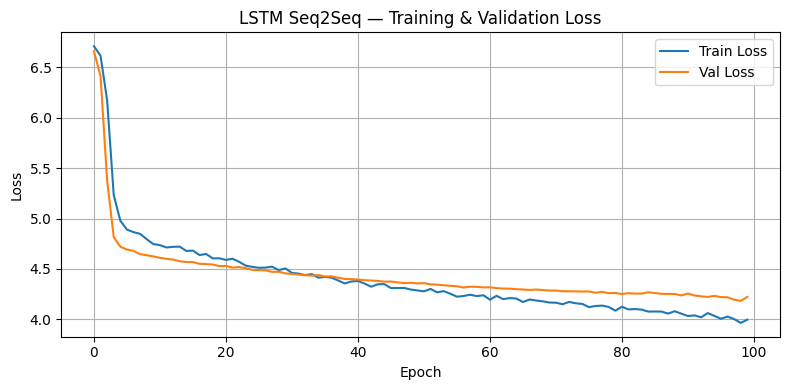

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses,  label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("LSTM Seq2Seq — Training & Validation Loss")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

In [23]:
for i in range(10):
    q   = test_df["question"].iloc[i]
    c   = test_df["context"].iloc[i]
    gt  = test_df["answer"].iloc[i]
    pred = predict_answer(model1,q, c)
    print(f"Q:    {q}")
    print(f"Pred: {pred}")
    print(f"GT:   {gt}")
    print("---")

Q:    ما الذي كشف عن قدرة أورسون ويلز على التأثير في الجمهور قبل دخوله السينما؟
Pred: في من على الى م باستخدام الصوت الجمهور
GT:   تقديم بث اذاعي تسبب في ذعر جماهيري واسع
---
Q:    كيف كانت طبيعة الإنتاج السينمائي في هوليوود قبل ظهور Citizen Kane؟
Pred: في لم الاسلوب مثل م السينمائي سعيدة انه
GT:   كانت تعتمد على انماط تقليدية ونهايات متوقعة
---
Q:    ما التغيير الأساسي الذي قدمه Citizen Kane في طريقة سرد القصة؟
Pred: في من الى عن م غير بشكل المشاهد
GT:   استخدام سرد غير خطي يبدا من النهاية
---
Q:    كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية كين؟
Pred: في من الى كين الاسلوب شخصية خلال كل
GT:   عرض الشخصية من زواي مختلفة ومتضاربة
---
Q:    ما الهدف من استخدام تقنية Deep Focus في الفيلم؟
Pred: في من عن او م التي المشهد بوضوح
GT:   تمكين المشاهد من رؤية جميع عناصر المشهد بوضوح واختيار م يركز عليه
---
Q:    كيف تم توظيف حركة الكاميرا داخل الفيلم؟
Pred: من كل الى ثابتة اساسي حركة الحالة لم
GT:   كوسيلة سرد تنقل المعنى وتدعم القصة
---
Q:    ما العامل الذي أدى إلى ضعف النجاح التجاري للفيل

In [24]:
def f1_score_tokens(predicted, ground_truth):
    pred_tokens = preprocess(predicted).split()
    gt_tokens   = preprocess(ground_truth).split()

    if not pred_tokens or not gt_tokens:
        return 0.0

    # Count common tokens
    pred_set = set(pred_tokens)
    gt_set   = set(gt_tokens)
    common   = pred_set & gt_set

    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall    = len(common) / len(gt_tokens)
    f1        = 2 * precision * recall / (precision + recall)
    return f1

def exact_match(predicted, ground_truth):
    return int(preprocess(predicted).strip() == preprocess(ground_truth).strip())



In [25]:
f1_scores = []
em_scores = []

for i in range(len(test_df)):
    q    = test_df["question"].iloc[i]
    c    = test_df["context"].iloc[i]
    gt   = test_df["answer"].iloc[i]
    pred = predict_answer(model1,q, c)

    f1_scores.append(f1_score_tokens(pred, gt))
    em_scores.append(exact_match(pred, gt))

print(f"Exact Match : {sum(em_scores)/len(em_scores)*100:.1f}%")
print(f"F1 Score    : {sum(f1_scores)/len(f1_scores)*100:.1f}%")

Exact Match : 0.0%
F1 Score    : 37.2%


In [26]:
def predict_answer_ordered(model,question, context, max_len=8):
    model.eval()
    inp = preprocess(question) + " [SEP] " + preprocess(context)
    enc = encode(inp, MAX_INPUT_LEN)
    src = torch.tensor(enc, dtype=torch.long).unsqueeze(0).to(DEVICE)

    stopwords = {'في','من','على','ما','هو','هي','كان','كانت','إلى',
                 'عن','مع','أن','لا','هذا','هذه','التي','الذي','أو',
                 'لم','يكن','ولا','ا','بل','ثم','قد','أي','كل'}

    allowed = set(enc) - {word2idx["<PAD>"], word2idx["<SOS>"],
                          word2idx.get("<UNK>", 1)}

    with torch.no_grad():
        hidden, cell = model.encoder(src)

    dec_input = torch.tensor([word2idx["<SOS>"]], dtype=torch.long).to(DEVICE)
    token_scores = {}
    seen = set()

    for step in range(max_len):
        with torch.no_grad():
            out, hidden, cell = model.decoder(dec_input, hidden, cell)

        mask = torch.full(out.shape, -float('inf')).to(DEVICE)
        for idx in allowed:
            if idx not in seen:
                mask[0][idx] = out[0][idx]
        if step == 0:
            mask[0][word2idx["<EOS>"]] = -float('inf')

        top = mask.argmax(1).item()
        if top == word2idx["<EOS>"]:
            break

        word = idx2word.get(top, "")
        if word and word not in stopwords:
            token_scores[word] = out[0][top].item()

        seen.add(top)
        dec_input = torch.tensor([top], dtype=torch.long).to(DEVICE)

    # Reorder by position in context
    ctx_tokens = preprocess(context).split()
    top_words  = sorted(token_scores.items(),
                        key=lambda x: x[1], reverse=True)[:5]
    top_set    = {w for w, _ in top_words}

    ordered = [w for w in ctx_tokens if w in top_set]

    # Deduplicate while preserving order
    seen_out = set()
    result   = []
    for w in ordered:
        if w not in seen_out:
            result.append(w)
            seen_out.add(w)

    return " ".join(result[:5]) if result else " ".join([w for w,_ in top_words[:3]])

In [27]:
for i in range(10):
    q   = test_df["question"].iloc[i]
    c   = test_df["context"].iloc[i]
    gt  = test_df["answer"].iloc[i]
    pred = predict_answer_ordered(model1,q, c)
    print(f"Q:    {q}")
    print(f"Pred: {pred}")
    print(f"GT:   {gt}")
    print("---")

Q:    ما الذي كشف عن قدرة أورسون ويلز على التأثير في الجمهور قبل دخوله السينما؟
Pred: الى الجمهور باستخدام الصوت
GT:   تقديم بث اذاعي تسبب في ذعر جماهيري واسع
---
Q:    كيف كانت طبيعة الإنتاج السينمائي في هوليوود قبل ظهور Citizen Kane؟
Pred: مثل سعيدة م الاسلوب
GT:   كانت تعتمد على انماط تقليدية ونهايات متوقعة
---
Q:    ما التغيير الأساسي الذي قدمه Citizen Kane في طريقة سرد القصة؟
Pred: غير الى المشاهد بشكل
GT:   استخدام سرد غير خطي يبدا من النهاية
---
Q:    كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية كين؟
Pred: كين خلال شخصية الاسلوب الى
GT:   عرض الشخصية من زواي مختلفة ومتضاربة
---
Q:    ما الهدف من استخدام تقنية Deep Focus في الفيلم؟
Pred: المشهد بوضوح او
GT:   تمكين المشاهد من رؤية جميع عناصر المشهد بوضوح واختيار م يركز عليه
---
Q:    كيف تم توظيف حركة الكاميرا داخل الفيلم؟
Pred: ثابتة الحالة حركة الى اساسي
GT:   كوسيلة سرد تنقل المعنى وتدعم القصة
---
Q:    ما العامل الذي أدى إلى ضعف النجاح التجاري للفيلم عند صدوره؟
Pred: هيرست التغطية الى الجمهور
GT:   الضغط الاعلامي والخوف من ن

In [28]:
f1_scores = []
em_scores = []

for i in range(len(test_df)):
    q    = test_df["question"].iloc[i]
    c    = test_df["context"].iloc[i]
    gt   = test_df["answer"].iloc[i]
    pred = predict_answer_ordered(model1,q, c)

    f1_scores.append(f1_score_tokens(pred, gt))
    em_scores.append(exact_match(pred, gt))

print(f"Exact Match : {sum(em_scores)/len(em_scores)*100:.1f}%")
print(f"F1 Score    : {sum(f1_scores)/len(f1_scores)*100:.1f}%")

Exact Match : 1.4%
F1 Score    : 40.2%


Experiment 2

In [29]:
missing = []
for _, row in train_df.iterrows():
    for word in preprocess(row["answer"]).split():
        if word not in word2idx:
            missing.append(word)

print(f"Missing answer words: {len(missing)}")
print(missing[:10])

Missing answer words: 139
['امتلاك', 'وفرض', 'ابط', 'تحولو', 'هجوم', 'ذكرى', 'حب', 'لزوجته', 'زائر', 'سنوي']


In [30]:
# After building word2idx, force important answer words in
important_words = []
for _, row in train_df.iterrows():
    for word in row["answer"].split():
        if word not in word2idx:
            important_words.append(word)

for word in set(important_words):
    if word not in word2idx:
        word2idx[word] = len(word2idx)
        idx2word[word2idx[word]] = word

# Update VOCAB_SIZE after adding all words
VOCAB_SIZE = len(word2idx)

print(f"Added {len(set(important_words))} answer words to vocab")
print(f"New vocab size: {len(word2idx)}")

Added 139 answer words to vocab
New vocab size: 969


In [31]:
# Add answer words first (Cell 27 — keep as is)
# Then immediately rebuild loaders:

train_dataset2 = QADataset(train_df)
test_dataset2  = QADataset(test_df)

train_loader = DataLoader(train_dataset2, batch_size=16, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset2,  batch_size=16, shuffle=False, collate_fn=collate_fn)

print("Loaders rebuilt with new vocab size:", VOCAB_SIZE)

Loaders rebuilt with new vocab size: 969


In [32]:
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_DIM  = 64    # was 256 — too big
HIDDEN_DIM = 128   # was 512 — too big
N_LAYERS   = 2
DROPOUT    = 0.5   # increase dropout to fight overfitting

# 3. More epochs with early stopping
N_EPOCHS = 100

# 4. Early stopping
best_val  = float('inf')
patience  = 0
PATIENCE  =  12
teacher_forcing_ratio = 0.5

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model2   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

optimizer = torch.optim.Adam(model2.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <PAD>

train_losses2, test_losses2 = [], []

for epoch in range(N_EPOCHS):
  # decay teacher forcing each epoch
    tf_ratio = max(0.1, teacher_forcing_ratio - (epoch * 0.03))

    # --- Train ---
    model2.train()
    epoch_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        output = model2(src, trg, teacher_forcing_ratio=tf_ratio)
        output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
        target = trg[:, 1:].reshape(-1)
        loss   = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    train_losses2.append(epoch_loss / len(train_loader))

    # --- Eval ---
    model2.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in test_loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            output = model2(src, trg, teacher_forcing_ratio=0)
            output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
            target = trg[:, 1:].reshape(-1)
            val_loss += criterion(output, target).item()
    test_losses2.append(val_loss / len(test_loader))

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses2[-1]:.4f} | Val Loss: {test_losses2[-1]:.4f}")

    if test_losses2[-1] < best_val:
        best_val = test_losses2[-1]
        patience = 0
        torch.save(model2.state_dict(), "best_model1.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} | Best val loss: {best_val:.4f}")
            break

Epoch 01 | Train Loss: 6.8568 | Val Loss: 6.8374
Epoch 02 | Train Loss: 6.7813 | Val Loss: 6.6270
Epoch 03 | Train Loss: 6.4356 | Val Loss: 5.9564
Epoch 04 | Train Loss: 5.8281 | Val Loss: 5.7629
Epoch 05 | Train Loss: 5.6491 | Val Loss: 5.6749
Epoch 06 | Train Loss: 5.5825 | Val Loss: 5.6588
Epoch 07 | Train Loss: 5.5180 | Val Loss: 5.6190
Epoch 08 | Train Loss: 5.5014 | Val Loss: 5.6272
Epoch 09 | Train Loss: 5.4458 | Val Loss: 5.5931
Epoch 10 | Train Loss: 5.4288 | Val Loss: 5.5962
Epoch 11 | Train Loss: 5.3950 | Val Loss: 5.5696
Epoch 12 | Train Loss: 5.3676 | Val Loss: 5.5497
Epoch 13 | Train Loss: 5.3429 | Val Loss: 5.5498
Epoch 14 | Train Loss: 5.3363 | Val Loss: 5.5237
Epoch 15 | Train Loss: 5.2918 | Val Loss: 5.5187
Epoch 16 | Train Loss: 5.2757 | Val Loss: 5.5093
Epoch 17 | Train Loss: 5.2634 | Val Loss: 5.5004
Epoch 18 | Train Loss: 5.2463 | Val Loss: 5.4945
Epoch 19 | Train Loss: 5.2225 | Val Loss: 5.4685
Epoch 20 | Train Loss: 5.1898 | Val Loss: 5.4578
Epoch 21 | Train Los

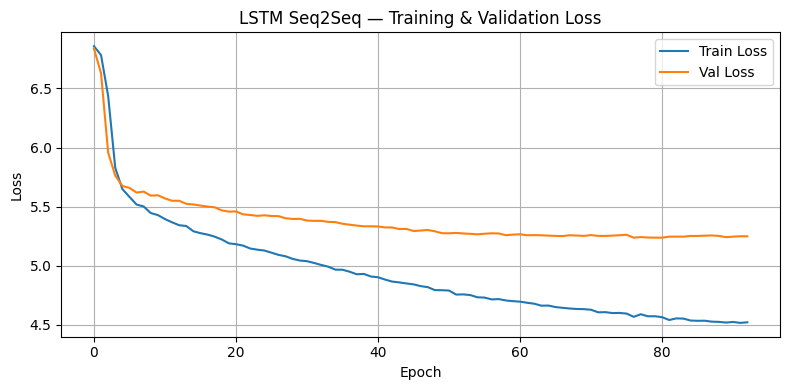

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses2, label="Train Loss")
plt.plot(test_losses2,  label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("LSTM Seq2Seq — Training & Validation Loss")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

In [34]:
for i in range(10):
    q   = test_df["question"].iloc[i]
    c   = test_df["context"].iloc[i]
    gt  = test_df["answer"].iloc[i]
    pred = predict_answer_ordered(model2,q, c)
    print(f"Q:    {q}")
    print(f"Pred: {pred}")
    print(f"GT:   {gt}")
    print("---")

Q:    ما الذي كشف عن قدرة أورسون ويلز على التأثير في الجمهور قبل دخوله السينما؟
Pred: الى الجمهور باستخدام الصوت
GT:   تقديم بث اذاعي تسبب في ذعر جماهيري واسع
---
Q:    كيف كانت طبيعة الإنتاج السينمائي في هوليوود قبل ظهور Citizen Kane؟
Pred: مثل سعيدة م الاسلوب
GT:   كانت تعتمد على انماط تقليدية ونهايات متوقعة
---
Q:    ما التغيير الأساسي الذي قدمه Citizen Kane في طريقة سرد القصة؟
Pred: الاسلوب غير الى بشكل
GT:   استخدام سرد غير خطي يبدا من النهاية
---
Q:    كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية كين؟
Pred: كين خلال شخصية الاسلوب الى
GT:   عرض الشخصية من زواي مختلفة ومتضاربة
---
Q:    ما الهدف من استخدام تقنية Deep Focus في الفيلم؟
Pred: المشهد بوضوح او
GT:   تمكين المشاهد من رؤية جميع عناصر المشهد بوضوح واختيار م يركز عليه
---
Q:    كيف تم توظيف حركة الكاميرا داخل الفيلم؟
Pred: ثابتة الحالة حركة الى اساسي
GT:   كوسيلة سرد تنقل المعنى وتدعم القصة
---
Q:    ما العامل الذي أدى إلى ضعف النجاح التجاري للفيلم عند صدوره؟
Pred: هيرست الى بين الجمهور
GT:   الضغط الاعلامي والخوف من نفوذ 

In [35]:
f1_scores = []
em_scores = []

for i in range(len(test_df)):
    q    = test_df["question"].iloc[i]
    c    = test_df["context"].iloc[i]
    gt   = test_df["answer"].iloc[i]
    pred = predict_answer_ordered(model2,q, c)

    f1_scores.append(f1_score_tokens(pred, gt))
    em_scores.append(exact_match(pred, gt))

print(f"Exact Match : {sum(em_scores)/len(em_scores)*100:.1f}%")
print(f"F1 Score    : {sum(f1_scores)/len(f1_scores)*100:.1f}%")

Exact Match : 4.2%
F1 Score    : 41.9%


 **Extractive span**

In [36]:
def find_answer_start(input_text, answer_text):
    # Both already preprocessed — just split and search
    input_tokens  = input_text.split()
    answer_tokens = answer_text.split()

    # 1. Exact match
    for i in range(len(input_tokens)):
        if input_tokens[i:i+len(answer_tokens)] == answer_tokens:
            return i, len(answer_tokens)

    # 2. Partial match — find position where most answer words appear
    best_pos   = -1
    best_score = 0
    answer_set = set(answer_tokens)

    for i in range(len(input_tokens)):
        window = input_tokens[i:i+len(answer_tokens)+2]
        score  = sum(1 for w in window if w in answer_set)
        if score > best_score:
            best_score = score
            best_pos   = i

    if best_score >= max(1, len(answer_tokens) // 2):  # found at least half
        return best_pos, len(answer_tokens)

    return -1, len(answer_tokens)


# Key fix: preprocess BOTH input and answer before searching
train_df["start_idx"]  = train_df.apply(
    lambda r: find_answer_start(
        preprocess(r["input"]),          # ← preprocess input too
        preprocess(r["answer"])
    )[0], axis=1)

train_df["answer_len"] = train_df.apply(
    lambda r: find_answer_start(
        preprocess(r["input"]),
        preprocess(r["answer"])
    )[1], axis=1)

test_df["start_idx"]   = test_df.apply(
    lambda r: find_answer_start(
        preprocess(r["input"]),
        preprocess(r["answer"])
    )[0], axis=1)

test_df["answer_len"]  = test_df.apply(
    lambda r: find_answer_start(
        preprocess(r["input"]),
        preprocess(r["answer"])
    )[1], axis=1)

# Check improvement
found_train = (train_df["start_idx"] != -1).sum()
found_test  = (test_df["start_idx"]  != -1).sum()
print(f"Found — Train: {found_train}/{len(train_df)} | Test: {found_test}/{len(test_df)}")

# Show remaining not-found
print("\nStill not found:")
not_found = train_df[train_df["start_idx"] == -1][["answer", "input"]]
for i, row in not_found.head(5).iterrows():
    print(f"  Answer : {row['answer']}")
    print(f"  Input  : {row['input'][:70]}...")
    print()

Found — Train: 132/168 | Test: 52/72

Still not found:
  Answer : تخليد ذكرى حب شاه جهان لزوجته
  Input  : م سبب بناء تاج محل [SEP] قرار شاه جهان انه يخلد قصة حبه هيبنيله اعظم ص...

  Answer : الكمال والانسجام
  Input  : ماذ يرمز التماثل في تصميم تاج محل [SEP] السيمترية رمز للمثالية والكمال...

  Answer : لان التصميم مستوحى من وصف الجنة ويتضمن الماء كعنصر اساسي في المشهد
  Input  : لماذ تم اختيار موقع تاج محل على نهر يامون [SEP] التصميم هيبقى مستوحى م...

  Answer : النقاء
  Input  : ماذ يرمز اللون الابيض في تاج محل [SEP] الابيض بيرمز للنقاء والاحمر بير...

  Answer : في غرفة اسفل الضريح
  Input  : اين توجد القبور الحقيقية داخل تاج محل [SEP] القبور الحقيقية موجودة في ...



In [37]:
# Show start_idx results cleanly
sample = train_df[["answer", "start_idx", "answer_len"]].copy()

print(f"{'#':<4} {'start':>6} {'len':>4}  answer")
print("-" * 50)
for i, row in sample.head(10).iterrows():
    status = "✓" if row["start_idx"] != -1 else "✗"
    print(f"{i:<4} {int(row['start_idx']):>6} {int(row['answer_len']):>4}  {status}  {row['answer']}")

#     start  len  answer
--------------------------------------------------
0        29    8  ✓  كل مادة من دول بتتحرك وبتتحول طول الوقت
1        22    4  ✓  بسبب حركته المجنونة والمستمرة
2        20    5  ✓  الحركة هي عصب الوجود بالكامل
3        22    5  ✓  امتلاك السلاح وفرض النظام بالقوة
4        27    6  ✓  وهي انتاج سلسلة من الحركات المعقدة
5        21    4  ✓  ل توجد حركة اصل
6        33    5  ✓  هنفضل ننصص الى م لانهاية
7        18    5  ✓  العالم حولن ثابت ل يتغير
8        24    7  ✓  هو مجرد وهم جاي من حواس بتخدعن
9        24    4  ✓  حطو اسس التفاضل والتكامل


In [41]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Make sure input column is already preprocessed
train_df["input_clean"] = train_df["input"].apply(preprocess)
test_df["input_clean"]  = test_df["input"].apply(preprocess)

class ExtractiveDataset(Dataset):
    def __init__(self, df):
        self.inputs  = [encode(row["input_clean"], MAX_INPUT_LEN) for _, row in df.iterrows()]
        self.starts  = [row["start_idx"]  for _, row in df.iterrows()]
        self.ends    = [row["start_idx"] + row["answer_len"] for _, row in df.iterrows()]

    def __len__(self): return len(self.inputs)

    def __getitem__(self, idx):
        return (torch.tensor(self.inputs[idx], dtype=torch.long),
                torch.tensor(self.starts[idx], dtype=torch.long),
                torch.tensor(self.ends[idx],   dtype=torch.long))

def ext_collate_fn(batch):
    inputs, starts, ends = zip(*batch)  # Unpack the batch
    inputs  = pad_sequence(inputs, batch_first=True, padding_value=0) # Pad input sequences
    starts  = torch.stack(starts) # Stack start indices
    ends    = torch.stack(ends)   # Stack end indices
    return inputs, starts, ends

# Instantiate the datasets
train_df_clean = train_df[train_df["start_idx"] != -1].reset_index(drop=True)
test_df_clean  = test_df[test_df["start_idx"]   != -1].reset_index(drop=True)

ext_train_dataset = ExtractiveDataset(train_df_clean)
ext_test_dataset  = ExtractiveDataset(test_df_clean)
print(f"Clean train: {len(train_df_clean)} | Clean test: {len(test_df_clean)}")

# Instantiate the DataLoaders with the custom collate_fn
ext_train_loader  = DataLoader(ext_train_dataset, batch_size=16, shuffle=True,  collate_fn=ext_collate_fn)
ext_test_loader   = DataLoader(ext_test_dataset,  batch_size=16, shuffle=False, collate_fn=ext_collate_fn)


Clean train: 132 | Clean test: 52


In [42]:
# ── 3. Model ─────────────────────────────────────────────────────────────────
class ExtractiveQA(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, n_layers,
                                 batch_first=True,
                                 dropout=dropout,
                                 bidirectional=True)   # reads both directions
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, 1)  # *2 because bidirectional

    def forward(self, x):
        embedded       = self.dropout(self.embedding(x))  # (batch, seq, embed)
        out, _         = self.lstm(embedded)               # (batch, seq, hidden*2)
        logits         = self.fc(out).squeeze(-1)          # (batch, seq)
        return logits                                       # score for each position

ext_model = ExtractiveQA(
    vocab_size = VOCAB_SIZE,
    embed_dim  = 64,
    hidden_dim = 128,
    n_layers   = 2,
    dropout    = 0.3
).to(DEVICE)

ext_optimizer = torch.optim.Adam(ext_model.parameters(), lr=1e-3, weight_decay=1e-4)
ext_criterion = nn.CrossEntropyLoss()

print(f"Extractive model parameters: {sum(p.numel() for p in ext_model.parameters()):,}")

Extractive model parameters: 656,193


In [43]:
# ── 4. Training ──────────────────────────────────────────────────────────────
ext_train_losses, ext_val_losses = [], []
ext_best_val  = float('inf')
ext_patience  = 0
EXT_PATIENCE  = 10
EXT_EPOCHS    = 60

for epoch in range(EXT_EPOCHS):

    # Train
    ext_model.train()
    epoch_loss = 0
    for inputs, starts, _ in ext_train_loader:
        inputs, starts = inputs.to(DEVICE), starts.to(DEVICE)
        ext_optimizer.zero_grad()
        logits = ext_model(inputs)                        # ← compute first
        starts = starts.clamp(0, logits.shape[1] - 1)    # ← then clamp
        loss   = ext_criterion(logits, starts)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ext_model.parameters(), 1.0)
        ext_optimizer.step()
        epoch_loss += loss.item()
    ext_train_losses.append(epoch_loss / len(ext_train_loader))

    # Validate
    ext_model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, starts, _ in ext_test_loader:
            inputs, starts = inputs.to(DEVICE), starts.to(DEVICE)
            logits = ext_model(inputs)                        # ← compute FIRST
            starts = starts.clamp(0, logits.shape[1] - 1)    # ← then clamp
            val_loss += ext_criterion(logits, starts).item()
    ext_val_losses.append(val_loss / len(ext_test_loader))

    print(f"Epoch {epoch+1:02d} | Train Loss: {ext_train_losses[-1]:.4f} | Val Loss: {ext_val_losses[-1]:.4f}")

    # Early stopping
    if ext_val_losses[-1] < ext_best_val:
        ext_best_val = ext_val_losses[-1]
        ext_patience = 0
        torch.save(ext_model.state_dict(), "best_extractive.pt")
    else:
        ext_patience += 1
        if ext_patience >= EXT_PATIENCE:
            print(f"Early stopping at epoch {epoch+1} | Best val: {ext_best_val:.4f}")
            break

ext_model.load_state_dict(torch.load("best_extractive.pt"))
ext_model.eval()
print(f"Best extractive model val loss: {ext_best_val:.4f}")

Epoch 01 | Train Loss: 3.5379 | Val Loss: 3.4895
Epoch 02 | Train Loss: 3.2436 | Val Loss: 3.1100
Epoch 03 | Train Loss: 2.8480 | Val Loss: 3.3025
Epoch 04 | Train Loss: 2.5726 | Val Loss: 3.0545
Epoch 05 | Train Loss: 2.4547 | Val Loss: 2.6521
Epoch 06 | Train Loss: 2.1718 | Val Loss: 2.6208
Epoch 07 | Train Loss: 2.0512 | Val Loss: 2.8588
Epoch 08 | Train Loss: 1.9453 | Val Loss: 2.1611
Epoch 09 | Train Loss: 1.6959 | Val Loss: 2.5388
Epoch 10 | Train Loss: 1.6446 | Val Loss: 2.0948
Epoch 11 | Train Loss: 1.5195 | Val Loss: 2.1894
Epoch 12 | Train Loss: 1.3053 | Val Loss: 2.4766
Epoch 13 | Train Loss: 1.2358 | Val Loss: 2.0863
Epoch 14 | Train Loss: 1.0702 | Val Loss: 1.8842
Epoch 15 | Train Loss: 1.0781 | Val Loss: 1.9534
Epoch 16 | Train Loss: 0.9707 | Val Loss: 1.8452
Epoch 17 | Train Loss: 0.7954 | Val Loss: 2.2366
Epoch 18 | Train Loss: 0.8345 | Val Loss: 1.6483
Epoch 19 | Train Loss: 0.7304 | Val Loss: 1.5574
Epoch 20 | Train Loss: 0.7118 | Val Loss: 2.0027
Epoch 21 | Train Los

In [44]:
def predict_extractive(question, context):
    ext_model.eval()

    # Build full input exactly as during training
    q_clean   = preprocess(question)
    c_clean   = preprocess(context)
    inp = q_clean + " [SEP] " + c_clean   # ← fix
    inp_tokens = inp.split()

    enc = encode(inp, MAX_INPUT_LEN)
    src = torch.tensor(enc, dtype=torch.long).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = ext_model(src)                    # (1, seq_len)

    # Mask PAD and question tokens — answer must come from context
    sep_pos = inp_tokens.index("[SEP]") if " [SEP] " in inp_tokens else 0

    for i in range(len(enc)):
        if enc[i] == 0:                            # PAD — block
            logits[0][i] = -float('inf')
        if i <= sep_pos:                           # question side — block
            logits[0][i] = -float('inf')

    start = logits.argmax(dim=1).item()

    # Get answer length for this specific sample from training stats
    # Use the actual answer length distribution
    ans_lengths = train_df["answer_len"].values
    avg_len     = max(2, int(round(ans_lengths.mean())))  # at least 2 words

    # Extract from the full input tokens at the predicted position
    end = min(start + avg_len, len(inp_tokens))
    answer = " ".join(inp_tokens[start:end])

    return answer

In [45]:
# ── 6. Evaluation ────────────────────────────────────────────────────────────
def f1_score_tokens(pred, gt):
    p_tok = preprocess(pred).split()
    g_tok = preprocess(gt).split()
    if not p_tok or not g_tok:
        return 0.0
    common    = set(p_tok) & set(g_tok)
    if not common:
        return 0.0
    precision = len(common) / len(p_tok)
    recall    = len(common) / len(g_tok)
    return 2 * precision * recall / (precision + recall)

def exact_match(pred, gt):
    return int(preprocess(pred).strip() == preprocess(gt).strip())

results = []
for i in range(len(test_df)):
    q    = test_df["question"].iloc[i]
    c    = test_df["context"].iloc[i]
    gt   = test_df["answer"].iloc[i]
    pred = predict_extractive(q, c)
    results.append({
        "question"    : q,
        "ground_truth": gt,
        "predicted"   : pred,
        "EM"          : exact_match(pred, gt),
        "F1"          : round(f1_score_tokens(pred, gt), 3)
    })

results_df = pd.DataFrame(results)

# ── Clean evaluation display ─────────────────────────────────────────────────
ext_model.load_state_dict(torch.load("best_extractive.pt"))
ext_model.eval()

results = []
for i in range(len(test_df)):
    q    = test_df["question"].iloc[i]
    c    = test_df["context"].iloc[i]
    gt   = test_df["answer"].iloc[i]
    pred = predict_extractive(q, c)
    f1   = f1_score_tokens(pred, gt)
    em   = exact_match(pred, gt)
    results.append({"question": q, "ground_truth": gt, "predicted": pred, "EM": em, "F1": f1})

results_df = pd.DataFrame(results)

# Print each sample cleanly
print("=" * 60)
for i, row in results_df.head(10).iterrows():
    print(f"Sample {i+1}")
    print(f"  Q  : {row['question']}")
    print(f"  GT : {row['ground_truth']}")
    print(f"  PRE: {row['predicted']}")
    print(f"  EM : {row['EM']}  |  F1 : {row['F1']:.2f}")
    print("-" * 60)

# Summary
print(f"\nExact Match : {results_df['EM'].mean()*100:.1f}%")
print(f"F1 Score    : {results_df['F1'].mean()*100:.1f}%")

Sample 1
  Q  : ما الذي كشف عن قدرة أورسون ويلز على التأثير في الجمهور قبل دخوله السينما؟
  GT : تقديم بث اذاعي تسبب في ذعر جماهيري واسع
  PRE: بد وكانه تقرير اخباري عن
  EM : 0  |  F1 : 0.00
------------------------------------------------------------
Sample 2
  Q  : كيف كانت طبيعة الإنتاج السينمائي في هوليوود قبل ظهور Citizen Kane؟
  GT : كانت تعتمد على انماط تقليدية ونهايات متوقعة
  PRE: افلام هوليوود تتبع قوالب ثابتة
  EM : 0  |  F1 : 0.00
------------------------------------------------------------
Sample 3
  Q  : ما التغيير الأساسي الذي قدمه Citizen Kane في طريقة سرد القصة؟
  GT : استخدام سرد غير خطي يبدا من النهاية
  PRE: الاسلوب غير الخطي كان مختلف
  EM : 0  |  F1 : 0.17
------------------------------------------------------------
Sample 4
  Q  : كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية كين؟
  GT : عرض الشخصية من زواي مختلفة ومتضاربة
  PRE: يتم تقديم حياة كين من
  EM : 0  |  F1 : 0.18
------------------------------------------------------------
Sample 5
  Q  : ما الهدف من 

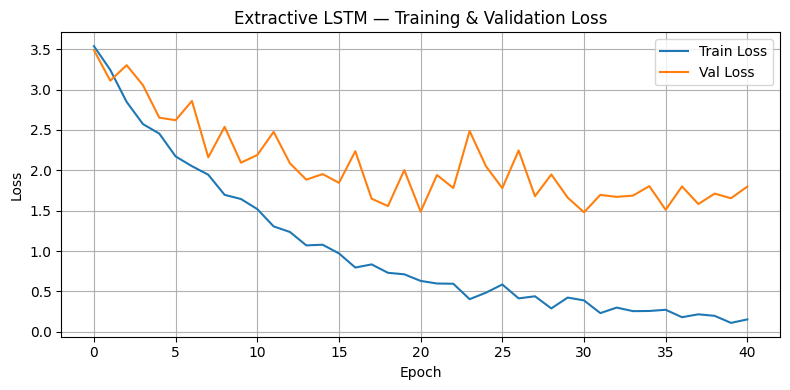

In [46]:
# ── 7. Loss curve ─────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(ext_train_losses, label="Train Loss")
plt.plot(ext_val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Extractive LSTM — Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("extractive_loss.png")
plt.show()